# Facial Landmark CSV Visualization (Notebook Version)

This notebook:
- Loads a landmarks CSV (MediaPipe-like `x_i, y_i, z_i` columns).
- Animates the landmarks as scatter + optional mesh (no background face).
- Plots **other numeric columns** as **one-column-per-image** line graphs (min–max normalized).
- Lets you tweak configuration in cells without editing a CLI script.

> Tip: GPU is **not** needed for this notebook. Everything is CPU-bound (pandas / matplotlib / ffmpeg).


Set the input CSV/video paths, output folder, frame rate, and plotting options before running later cells.


In [40]:
# =======================
# CONFIGURATION
# =======================
CSV_PATH = "./demo_vids/M22911_30FPS_1Face.csv"   # <-- change this to your CSV path
OUTDIR = "./demo_vids"          # where to save figures/animations
FPS = 30                                       # MP4 frame rate
MAX_FRAMES = 0                              # subsample to at most this many frames; set 0 for all
DRAW_MESH = True                               
MAX_SERIES_PER_LEGEND = 20                     # only used if we show legends
NORMALIZE_TIMESERIES = True                    # min-max normalization
SPLIT_BATCH_SIZE = 20                           # plot N columns per *run* (each column still saved as its own PNG)
                                               # just to avoid huge loops in a single cell if you have many columns

# Optional: limit which non-landmark columns to plot (None = all)
INCLUDE_COLUMNS = None   # e.g., ["visibility", "presence", "pitch", "yaw", "roll"]
EXCLUDE_COLUMNS = None   # e.g., columns you want to skip

# Reproducibility / sampling
RANDOM_SEED = 123


Set the input CSV/video paths, output folder, frame rate, and plotting options before running later cells.


In [41]:
# Imports
import os, re, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.tri as mtri
from matplotlib.animation import FFMpegWriter
from pathlib import Path

# Create output dir
outdir = Path(OUTDIR)
outdir.mkdir(parents=True, exist_ok=True)

# # Helpers for pretty display
# from caas_jupyter_tools import display_dataframe_to_user

print(f"Using CSV: {CSV_PATH}\nSaving to: {outdir}")

Using CSV: ./demo_vids/M22911_30FPS_1Face.csv
Saving to: demo_vids


Load the PyAFAR CSV and preview its shape so later cells know which rows and columns are available.


In [42]:
# Load CSV & preview
df = pd.read_csv(CSV_PATH)
print(f"DataFrame shape: {df.shape}")
display(df.head(2))

DataFrame shape: (8717, 1420)


,Frame,Face_Index,Pitch,Yaw,Roll,Eye Aspect Ratio,Mouth Aspect Ratio,Occ_au_1,Occ_au_2,Occ_au_3,...,z_464,x_465,y_465,z_465,x_466,y_466,z_466,x_467,y_467,z_467
0,0,-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1,-1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Find the MediaPipe landmark triplets (`x_i`, `y_i`, `z_i`) so the notebook can separate landmarks from other numeric signals.


In [43]:
# Detect landmark columns forming triplets (x_i, y_i, z_i)

def detect_landmark_columns(df):
    patterns = [
        (re.compile(r"^x[_]?(\d+)$"), re.compile(r"^y[_]?(\d+)$"), re.compile(r"^z[_]?(\d+)$")),
        (re.compile(r"^x_(\d+)$"), re.compile(r"^y_(\d+)$"), re.compile(r"^z_(\d+)$")),
        (re.compile(r"^landmark[_-]?(\d+)_x$"), re.compile(r"^landmark[_-]?(\d+)_y$"), re.compile(r"^landmark[_-]?(\d+)_z$")),
        (re.compile(r"^x\[(\d+)\]$"), re.compile(r"^y\[(\d+)\]$"), re.compile(r"^z\[(\d+)\]$")),
    ]
    x_cols, y_cols, z_cols = {}, {}, {}
    for col in df.columns:
        col_s = col.strip()
        matched = False
        for rx, ry, rz in patterns:
            if rx.match(col_s):
                i = int(rx.match(col_s).group(1)); x_cols[i] = col; matched = True; break
            if ry.match(col_s):
                i = int(ry.match(col_s).group(1)); y_cols[i] = col; matched = True; break
            if rz.match(col_s):
                i = int(rz.match(col_s).group(1)); z_cols[i] = col; matched = True; break
        if not matched:
            continue

    # fallback: generic x_#, y_#, z_#
    if not (set(x_cols) and set(y_cols) and set(z_cols)):
        rx = re.compile(r"^x[_-]?(\d+)$", re.IGNORECASE)
        ry = re.compile(r"^y[_-]?(\d+)$", re.IGNORECASE)
        rz = re.compile(r"^z[_-]?(\d+)$", re.IGNORECASE)
        for col in df.columns:
            m = rx.match(col);  m and x_cols.setdefault(int(m.group(1)), col)
            m = ry.match(col);  m and y_cols.setdefault(int(m.group(1)), col)
            m = rz.match(col);  m and z_cols.setdefault(int(m.group(1)), col)

    idxs = sorted(set(x_cols.keys()) & set(y_cols.keys()) & set(z_cols.keys()))
    return idxs, x_cols, y_cols, z_cols

idxs, x_cols, y_cols, z_cols = detect_landmark_columns(df)
print(f"Detected landmarks: {len(idxs)}")

Detected landmarks: 468


Prepare helper functions for drawing landmark scatter points and optional mesh connections.


In [44]:
# Triangulation helper

def base_triangulation(df, idxs, x_cols, y_cols, draw_mesh=True):
    if not draw_mesh or len(idxs) < 3:
        return None

    # Find a row with at least 3 unique (x, y) points
    for _, row in df.iterrows():
        x0 = row[[x_cols[i] for i in idxs]].to_numpy(dtype=float)
        y0 = row[[y_cols[i] for i in idxs]].to_numpy(dtype=float)
        if not (np.all(np.isfinite(x0)) and np.all(np.isfinite(y0))):
            continue
        y0_disp = 1.0 - y0
        pts = np.column_stack([x0, y0_disp])
        if len(np.unique(pts, axis=0)) < 3:
            continue
        return mtri.Triangulation(x0, y0_disp)

    return None

triang = base_triangulation(df, idxs, x_cols, y_cols, draw_mesh=DRAW_MESH)
triang is not None


True

# Landmarks only, on empty axes

### This cell outputs the landmark on xy axis, without original video


Prepare helper functions for drawing landmark scatter points and optional mesh connections.


In [45]:
# Animate landmarks (scatter + optional mesh)
mp4_path = outdir / "demo_30FPS_ptonly.mp4"

USE_ASPECT_STRETCH = True  # True -> display in 4:3; False -> keep square (0..1 x 0..1)

n_frames = len(df)
step = max(1, n_frames // MAX_FRAMES) if MAX_FRAMES else 1
frames_idx = list(range(0, n_frames, step))

fig = plt.figure(figsize=(12, 9))
ax = plt.gca()
ax.set_aspect('auto') 
ax.set_title("Facial Landmarks")



scatter = ax.scatter([], [], s=8)
holders = {"mesh": None, "bbox": None}

def update_frame(irow):
    row = df.iloc[irow]
    xs = row[[x_cols[i] for i in idxs]].to_numpy(dtype=float)
    ys = 1.0 - row[[y_cols[i] for i in idxs]].to_numpy(dtype=float)

    scatter.set_offsets(np.c_[xs, ys])

    if triang is not None:
        tri = mtri.Triangulation(xs, ys, triangles=triang.triangles)
        if holders["mesh"] is not None:
            for coll in holders["mesh"]:
                coll.remove()
        holders["mesh"] = ax.triplot(tri, linewidth=0.5)

    xmin, xmax = float(np.nanmin(xs)), float(np.nanmax(xs))
    ymin, ymax = float(np.nanmin(ys)), float(np.nanmax(ys))
    pad = 0.02
    xmin, xmax = max(0, xmin - pad), min(1, xmax + pad)
    ymin, ymax = max(0, ymin - pad), min(1, ymax + pad)
    if holders["bbox"] is not None:
        holders["bbox"].remove()
    holders["bbox"] = plt.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin, fill=False, linewidth=1.0)
    ax.add_patch(holders["bbox"])

    ax.set_xlim(0, 1); ax.set_ylim(0, 1)

writer = FFMpegWriter(fps=FPS, metadata=dict(artist="landmark_viz_notebook"), bitrate=1800)
with writer.saving(fig, str(mp4_path), dpi=150):
    for idx in frames_idx:
        update_frame(idx)
        writer.grab_frame()

plt.close(fig)
print(f"Saved animation to: {mp4_path}")

Saved animation to: demo_vids/demo_30FPS_ptonly.mp4


Set the input CSV/video paths, output folder, frame rate, and plotting options before running later cells.


In [ ]:
# # --- OVERLAY LANDMARKS ON VIDEO (pixel-accurate) ---

# import cv2
# import numpy as np
# import pandas as pd
# import matplotlib.tri as mtri
# from pathlib import Path

# # ========= CONFIG =========
# VIDEO_PATH = "./infant_input/tes_full.mp4"      # <-- set this
# CSV_PATH   = CSV_PATH                           # reuse from earlier, or set a string path
# OUT_VIDEO  = outdir / "video_with_landmarks_blue.mp4"

# DRAW_MESH = True
# POINT_RADIUS = 1
# POINT_THICK  = -1   # -1 = filled circle
# MESH_WIDTH   = 1

# # How your CSV coords are defined:
# COORD_SPACE = "frame"   # "frame"  -> x,y in [0,1] of full frame (most common)
#                         # "bbox"   -> x,y in [0,1] of a face crop; requires bbox columns

# # If COORD_SPACE == "bbox", tell me the bbox columns and their scale.
# # Supported styles:
# #   (1) normalized [0,1] bbox: xmin_norm, ymin_norm, xmax_norm, ymax_norm
# #   (2) pixel bbox: bb_left, bb_top, bb_width, bb_height  (all in pixels)
# BBOX_STYLE = "auto"  # "auto", "norm", or "pixel"
# BBOX_NORM_COLS  = ("xmin", "ymin", "xmax", "ymax")         # normalized [0,1]
# BBOX_PIXEL_COLS = ("bb_left", "bb_top", "bb_width", "bb_height")

# # Landmark column naming patterns (same detection logic as before)
# import re
# def detect_landmark_columns(df):
#     patterns = [
#         (re.compile(r"^x[_]?(\d+)$"), re.compile(r"^y[_]?(\d+)$"), re.compile(r"^z[_]?(\d+)$")),
#         (re.compile(r"^x_(\d+)$"), re.compile(r"^y_(\d+)$"), re.compile(r"^z_(\d+)$")),
#         (re.compile(r"^landmark[_-]?(\d+)_x$"), re.compile(r"^landmark[_-]?(\d+)_y$"), re.compile(r"^landmark[_-]?(\d+)_z$")),
#         (re.compile(r"^x\[(\d+)\]$"), re.compile(r"^y\[(\d+)\]$"), re.compile(r"^z\[(\d+)\]$")),
#     ]
#     x_cols, y_cols, z_cols = {}, {}, {}
#     for col in df.columns:
#         col_s = col.strip()
#         for rx, ry, rz in patterns:
#             if rx.match(col_s): x_cols[int(rx.match(col_s).group(1))] = col; break
#             if ry.match(col_s): y_cols[int(ry.match(col_s).group(1))] = col; break
#             if rz.match(col_s): z_cols[int(rz.match(col_s).group(1))] = col; break
#     # fallback generic x_#, y_#, z_#
#     if not (set(x_cols) and set(y_cols)):
#         rx = re.compile(r"^x[_-]?(\d+)$", re.IGNORECASE)
#         ry = re.compile(r"^y[_-]?(\d+)$", re.IGNORECASE)
#         rz = re.compile(r"^z[_-]?(\d+)$", re.IGNORECASE)
#         for col in df.columns:
#             m = rx.match(col); m and x_cols.setdefault(int(m.group(1)), col)
#             m = ry.match(col); m and y_cols.setdefault(int(m.group(1)), col)
#             m = rz.match(col); m and z_cols.setdefault(int(m.group(1)), col)
#     idxs = sorted(set(x_cols) & set(y_cols))  # z is optional for overlay
#     return idxs, x_cols, y_cols, z_cols

# # Load data
# df = pd.read_csv(CSV_PATH)
# idxs, x_cols, y_cols, z_cols = detect_landmark_columns(df)
# assert len(idxs) > 0, "No (x_i, y_i) landmark columns detected."

# # Open video
# cap = cv2.VideoCapture(str(VIDEO_PATH))
# assert cap.isOpened(), f"Failed to open video: {VIDEO_PATH}"
# fps = cap.get(cv2.CAP_PROP_FPS)
# W   = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
# H   = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
# fourcc = cv2.VideoWriter_fourcc(*"mp4v")
# writer = cv2.VideoWriter(str(OUT_VIDEO), fourcc, fps, (W, H))
# print(f"Video FPS={fps:.3f}, size={W}x{H}")

# # Determine bbox style if needed
# def detect_bbox_style(df):
#     norm_ok = all(c in df.columns for c in BBOX_NORM_COLS)
#     pix_ok  = all(c in df.columns for c in BBOX_PIXEL_COLS)
#     if norm_ok and pix_ok:
#         return "norm"  # prefer normalized if both exist
#     if norm_ok:
#         return "norm"
#     if pix_ok:
#         return "pixel"
#     return None

# if COORD_SPACE == "bbox":
#     style = detect_bbox_style(df) if BBOX_STYLE == "auto" else BBOX_STYLE
#     assert style in ("norm", "pixel"), "COORD_SPACE='bbox' but bbox columns not found."
# else:
#     style = None

# # Build a *pixel-space* triangulation using the first frame's points
# def frame_points_pixels(row):
#     xs = row[[x_cols[i] for i in idxs]] .to_numpy(dtype=float)
#     ys = row[[y_cols[i] for i in idxs]].to_numpy(dtype=float)

#     if COORD_SPACE == "frame":
#         # x,y are normalized to full frame, top-left origin in OpenCV
#         xp = (xs * W).astype(np.float32)
#         yp = (ys * H).astype(np.float32)

#     elif COORD_SPACE == "bbox":
#         if style == "norm":
#             xmin, ymin, xmax, ymax = (float(row[BBOX_NORM_COLS[0]]),
#                                       float(row[BBOX_NORM_COLS[1]]),
#                                       float(row[BBOX_NORM_COLS[2]]),
#                                       float(row[BBOX_NORM_COLS[3]]))
#             # bbox given as normalized to frame
#             xp = ((xmin + xs * (xmax - xmin)) * W).astype(np.float32)
#             yp = ((ymin + ys * (ymax - ymin)) * H).astype(np.float32)
#         else:  # pixel bbox
#             left, top, bw, bh = (float(row[BBOX_PIXEL_COLS[0]]),
#                                  float(row[BBOX_PIXEL_COLS[1]]),
#                                  float(row[BBOX_PIXEL_COLS[2]]),
#                                  float(row[BBOX_PIXEL_COLS[3]]))
#             xp = (left + xs * bw).astype(np.float32)
#             yp = (top  + ys * bh).astype(np.float32)
#     else:
#         raise ValueError("Unknown COORD_SPACE")

#     return xp, yp

# # triangulation from first available row
# triangles = None
# if DRAW_MESH and len(idxs) >= 3:
#     x0, y0 = frame_points_pixels(df.iloc[0])
#     # matplotlib wants x to the right and y upward; but triangle connectivity is the same
#     # We'll just generate the mesh in pixel space (OpenCV's origin top-left doesn't matter here).
#     tri = mtri.Triangulation(x0, y0)
#     triangles = tri.triangles  # (n_triangles, 3) integer indices

# # Iterate frames
# n_csv = len(df)
# n_vid = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
# n = min(n_csv, n_vid)
# print(f"Rendering {n} frames (min of CSV rows and video frames)")

# for i in range(n):
#     ret, frame = cap.read()
#     if not ret:
#         break

#     row = df.iloc[i]
#     xp, yp = frame_points_pixels(row)

#     # draw points
#     for x, y in zip(xp, yp):
#         # cv2.circle(frame, (int(round(x)), int(round(y))), POINT_RADIUS, (255, 200, 0), POINT_THICK, lineType=cv2.LINE_AA)
#         # BLUE dots, thin
#         cv2.circle(frame, (int(round(x)), int(round(y))), 1, (255, 0, 0), -1, lineType=cv2.LINE_AA)


#     # draw mesh
#     if triangles is not None:
#         for a, b, c in triangles:
#             p1 = (int(round(xp[a])), int(round(yp[a])))
#             p2 = (int(round(xp[b])), int(round(yp[b])))
#             p3 = (int(round(xp[c])), int(round(yp[c])))
#             # cv2.line(frame, p1, p2, (0, 255, 255), MESH_WIDTH, lineType=cv2.LINE_AA)
#             # cv2.line(frame, p2, p3, (0, 255, 255), MESH_WIDTH, lineType=cv2.LINE_AA)
#             # cv2.line(frame, p3, p1, (0, 255, 255), MESH_WIDTH, lineType=cv2.LINE_AA)
#             # BLUE thin lines
#             cv2.line(frame, p1, p2, (255, 0, 0), 1, lineType=cv2.LINE_AA)
#             cv2.line(frame, p2, p3, (255, 0, 0), 1, lineType=cv2.LINE_AA)
#             cv2.line(frame, p3, p1, (255, 0, 0), 1, lineType=cv2.LINE_AA)

#     writer.write(frame)

# cap.release()
# writer.release()
# print(f"Saved: {OUT_VIDEO}")


Video FPS=30.003, size=1620x1080
Rendering 908 frames (min of CSV rows and video frames)
Saved: visualize_infant/video_with_landmarks_blue.mp4


### This cell outputs the video with facial landmark overlay

Import the analysis and plotting libraries, create the output directory, and confirm where files will be saved.


In [55]:
# --- PIXEL-ACCURATE OVERLAY (video background + landmark scatter + mesh) ---

import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as mtri
from matplotlib.animation import FFMpegWriter
from pathlib import Path


# ========= CONFIG =========
VIDEO_PATH = "./demo_vids/M22911_30FPS.mp4"
OUT_VIDEO  = outdir / "demo_30FPS_landmark_overlay.mp4"

USE_VIDEO_FPS  = True
POINT_SIZE     = 8
MESH_LINEWIDTH = 0.5


# ========= PREP DATA =========
# ensure df sorted by frame
df = df.sort_values("Frame").reset_index(drop=True)

START_FRAME = 2700 # int(df["Frame"].iloc[0])
END_FRAME   = 4500 # int(df["Frame"].iloc[-1])


# --------- open video ----------
cap = cv2.VideoCapture(str(VIDEO_PATH))
if not cap.isOpened():
    raise RuntimeError(f"Could not open video: {VIDEO_PATH}")

vid_w  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
vid_h  = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
vid_fps = cap.get(cv2.CAP_PROP_FPS) or 0.0
total_frames_video = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

n_frames = END_FRAME - START_FRAME + 1
if n_frames <= 0:
    cap.release()
    raise RuntimeError("Invalid frame range from df.")

if USE_VIDEO_FPS and vid_fps > 0:
    out_fps = vid_fps
else:
    out_fps = FPS

print(f"Video size: {vid_w}x{vid_h}, total frames: {total_frames_video}")
print(f"Using frames: {START_FRAME} → {END_FRAME} ({n_frames})")
print(f"Output FPS: {out_fps}")
print(f"Saving overlay video to: {OUT_VIDEO}")


# --------- initialize first frame ----------
cap.set(cv2.CAP_PROP_POS_FRAMES, START_FRAME)

ret, frame0 = cap.read()
if not ret:
    cap.release()
    raise RuntimeError("Failed to read first frame.")

frame0_rgb = cv2.cvtColor(frame0, cv2.COLOR_BGR2RGB)


# --------- FULLSCREEN FIGURE ----------
fig = plt.figure(figsize=(vid_w / 100, vid_h / 100), dpi=100)
ax = fig.add_axes([0, 0, 1, 1])  # full canvas
ax.axis("off")

plt.subplots_adjust(left=0, right=1, top=1, bottom=0)


# --------- background image ----------
img_artist = ax.imshow(
    frame0_rgb,
    extent=(0, vid_w, vid_h, 0),
    origin='upper'
)

scatter = ax.scatter([], [], s=POINT_SIZE)

holders = {"mesh": None}
triangles = triang.triangles if (triang is not None) else None


# --------- UPDATE FUNCTION ----------
def update_frame(irow, frame_bgr):
    frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
    img_artist.set_data(frame_rgb)

    row = df.iloc[irow]

    xs = row[[x_cols[i] for i in idxs]].to_numpy(dtype=float)
    ys = row[[y_cols[i] for i in idxs]].to_numpy(dtype=float)

    xp = xs * vid_w
    yp = ys * vid_h

    # handle invalid points (0,0)
    valid = (xp > 0) & (yp > 0)
    scatter.set_offsets(np.c_[xp[valid], yp[valid]])

    # update mesh
    if triangles is not None:
        tri_pix = mtri.Triangulation(xp, yp, triangles=triangles)
        if holders["mesh"] is not None:
            for coll in holders["mesh"]:
                coll.remove()
        holders["mesh"] = ax.triplot(tri_pix, linewidth=MESH_LINEWIDTH)

    ax.set_xlim(0, vid_w)
    ax.set_ylim(vid_h, 0)


# --------- WRITE VIDEO ----------
writer = FFMpegWriter(
    fps=out_fps,
    metadata=dict(artist="landmark_viz_notebook"),
    bitrate=1800
)

df_idx = 0

with writer.saving(fig, str(OUT_VIDEO), dpi=100):

    for frame_id in tqdm(range(START_FRAME, END_FRAME + 1)):

        ret, frame = cap.read()
        if not ret:
            break

        if df_idx < len(df) and frame_id == df.iloc[df_idx]["Frame"]:
            update_frame(df_idx, frame)
            df_idx += 1
        else:
            # no landmark → just clear points
            scatter.set_offsets(np.empty((0, 2)))

        writer.grab_frame()


cap.release()
plt.close(fig)

print(f"Saved pixel-accurate overlay video to: {OUT_VIDEO}")

Video size: 1508x852, total frames: 8717
Using frames: 2700 → 4500 (1801)
Output FPS: 30.0
Saving overlay video to: demo_vids/demo_30FPS_landmark_overlay.mp4


100%|██████████| 1801/1801 [00:42<00:00, 41.98it/s]


Saved pixel-accurate overlay video to: demo_vids/demo_30FPS_landmark_overlay.mp4


# Line Graphs Only

Select numeric columns that are not landmark coordinates, such as frame numbers, pose, aspect ratios, and AU scores.


In [46]:
# Identify non-landmark numeric columns
lm_cols = {x_cols[i] for i in idxs} | {y_cols[i] for i in idxs} | {z_cols[i] for i in idxs}
numeric_cols = [c for c in df.columns if c not in lm_cols and pd.api.types.is_numeric_dtype(df[c])]

# Optional include/exclude filters
if INCLUDE_COLUMNS is not None:
    numeric_cols = [c for c in numeric_cols if c in set(INCLUDE_COLUMNS)]
if EXCLUDE_COLUMNS is not None:
    numeric_cols = [c for c in numeric_cols if c not in set(EXCLUDE_COLUMNS)]

print(f"Total non-landmark numeric columns: {len(numeric_cols)}")
numeric_cols[:10]

Total non-landmark numeric columns: 16


['Frame',
 'Face_Index',
 'Pitch',
 'Yaw',
 'Roll',
 'Eye Aspect Ratio',
 'Mouth Aspect Ratio',
 'Occ_au_1',
 'Occ_au_2',
 'Occ_au_3']

Normalize selected time-series columns so signals with different scales can be plotted together or compared visually.


In [47]:
# Prepare a normalized copy for plotting
ts = df[numeric_cols].copy()

if NORMALIZE_TIMESERIES:
    for c in numeric_cols:
        s = ts[c].astype(float)
        mn = np.nanmin(s); mx = np.nanmax(s)
        if np.isfinite(mn) and np.isfinite(mx) and mx != mn:
            ts[c] = (s - mn) / (mx - mn)

print("Prepared time series (normalized)" if NORMALIZE_TIMESERIES else "Prepared time series (raw)")

Prepared time series (normalized)


Save one PNG line plot per selected numeric column.


In [48]:
# Plot each numeric column as ONE image (one-column-per-image), batched to avoid huge loops in one cell.

def plot_one_column(cname, outdir):
    fig = plt.figure(figsize=(10, 3.5))
    ax = plt.gca()
    ax.plot(ts.index.values, ts[cname].values, linewidth=1.0)
    ax.set_xlabel("Frame")
    ax.set_ylabel("Normalized value" if NORMALIZE_TIMESERIES else "Value")
    ax.set_title(cname)
    fig.tight_layout()
    out_path = Path(outdir) / f"ts_{cname}.png"
    fig.savefig(out_path, dpi=150)
    plt.close(fig)
    return out_path

# Batch over columns
saved = []
for i, cname in enumerate(numeric_cols):
    p = plot_one_column(cname, outdir)
    saved.append(str(p))
    if (i+1) % max(1, SPLIT_BATCH_SIZE) == 0:
        print(f"...saved {i+1}/{len(numeric_cols)}")

print(f"Saved {len(saved)} one-column images to {outdir}")

Saved 16 one-column images to demo_vids


Print a small sample of generated plot files to quickly confirm the output folder contents.


In [ ]:
# List a few generated per-column images
from itertools import islice
print("Sample outputs:")
for p in islice(sorted(outdir.glob("ts_*.png")), 10):
    print(" -", p)

Run the next code cell: from pathlib import Path.


In [49]:
from pathlib import Path

# columns that are NOT landmarks and are numeric
lm_cols = {x_cols[i] for i in idxs} | {y_cols[i] for i in idxs} | {z_cols[i] for i in idxs}
numeric_cols = [
    c for c in df.columns
    if c not in lm_cols and pd.api.types.is_numeric_dtype(df[c])
]

# optional include/exclude filters if you were using them
if INCLUDE_COLUMNS:
    numeric_cols = [c for c in numeric_cols if any(inc in c for inc in INCLUDE_COLUMNS)]
if EXCLUDE_COLUMNS:
    numeric_cols = [c for c in numeric_cols if all(exc not in c for exc in EXCLUDE_COLUMNS)]

print(f"{len(numeric_cols)} numeric non-landmark columns")

# build time-series DataFrame aligned with df rows
ts = df[numeric_cols].copy()

if NORMALIZE_TIMESERIES:
    for c in numeric_cols:
        s = ts[c].astype(float)
        mn = np.nanmin(s)
        mx = np.nanmax(s)
        if np.isfinite(mn) and np.isfinite(mx) and mx != mn:
            ts[c] = (s - mn) / (mx - mn)

print("ts shape:", ts.shape)
ts_au_cols = [x for x in ts.columns if "au" in x]
ts = ts.loc[:, ts_au_cols]
print("ts shape:", ts.shape)
print(ts.columns)


16 numeric non-landmark columns
ts shape: (8717, 16)
ts shape: (8717, 9)
Index(['Occ_au_1', 'Occ_au_2', 'Occ_au_3', 'Occ_au_4', 'Occ_au_6', 'Occ_au_9',
       'Occ_au_12', 'Occ_au_20', 'Occ_au_28'],
      dtype='object')


### This cell outputs the line graph of AUs with moving tick. The original video is next to those graphs.

Import the analysis and plotting libraries, create the output directory, and confirm where files will be saved.


In [56]:
# --- FAST VIDEO + TIME-SERIES (NO LANDMARKS, NO FRAME SKIP) ---

import cv2
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FFMpegWriter
from tqdm import tqdm
import math

# ========= CONFIG =========
VIDEO_PATH = "./demo_vids/M22911_30FPS.mp4"
OUT_VIDEO  = outdir / "demo_30FPS_0130to0230.mp4"

START_FRAME = 2700
END_FRAME   = 4500

MAX_TS_ROWS = 4

# ========= AU LABELS =========
AU_LABELS = {
    1:  "Inner Brow Raise",
    2:  "Outer Brow Raise",
    3:  "Inner Brow Tightener",
    4:  "Brow Lowerer",
    6:  "Cheek Raise",
    9:  "Nose Wrinkle",
    12: "Lip Corner Pull",
    20: "Lip Stretch",
    28: "Lip Suck",
}

def extract_au_name(col):
    if "au_" in col:
        try:
            num = int(col.split("au_")[1])
            return f"AU{num}: {AU_LABELS.get(num, 'Unknown')}"
        except:
            pass
    return col

# ========= FILTER DATA =========
mask = (df["Frame"] >= START_FRAME) & (df["Frame"] <= END_FRAME)

df = df.loc[mask].copy()
ts = ts.loc[mask].copy()

df = df.reset_index(drop=True)
ts = ts.reset_index(drop=True)

plot_cols = ts.columns
n_ts = len(plot_cols)

# ========= VIDEO =========
cap = cv2.VideoCapture(VIDEO_PATH)
if not cap.isOpened():
    raise RuntimeError("Cannot open video")

vid_w  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
vid_h  = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
vid_fps = cap.get(cv2.CAP_PROP_FPS)

print(f"Video FPS: {vid_fps}")

# ========= INITIAL FRAME =========
cap.set(cv2.CAP_PROP_POS_FRAMES, START_FRAME)
ret, frame0 = cap.read()
if not ret:
    raise RuntimeError("Cannot read first frame")

frame0_rgb = cv2.cvtColor(frame0, cv2.COLOR_BGR2RGB)

# ========= LAYOUT =========
n_rows = min(MAX_TS_ROWS, n_ts)
n_ts_cols = math.ceil(n_ts / n_rows)

fig_height = max(9, 2.8 * n_rows)
fig = plt.figure(figsize=(24, fig_height))

gs = fig.add_gridspec(
    nrows=n_rows,
    ncols=n_ts_cols + 1,
    width_ratios=[3.5] + [1] * n_ts_cols  # 👈 big video
)
gs.update(hspace=0.4, wspace=0.15)

# ========= VIDEO PANEL =========
ax_vid = fig.add_subplot(gs[:, 0])
ax_vid.axis('off')
ax_vid.set_aspect('auto')

img_artist = ax_vid.imshow(frame0_rgb)

# ========= TIME SERIES =========
ts_axes = []
ts_vlines = []

x_vals = df["Frame"].values

for k, cname in enumerate(plot_cols):
    row = k % n_rows
    col = k // n_rows

    ax_ts = fig.add_subplot(gs[row, col + 1])
    y_vals = ts[cname].values.astype(float)

    ax_ts.plot(x_vals, y_vals, linewidth=1.0)
    ax_ts.set_title(extract_au_name(cname), fontsize=8)
    ax_ts.set_xlabel("Frame", fontsize=7)
    ax_ts.set_ylabel("Value", fontsize=7)

    vline = ax_ts.axvline(x_vals[0], color='r', linestyle='--')

    ts_axes.append(ax_ts)
    ts_vlines.append(vline)

# ========= WRITE VIDEO =========
writer = FFMpegWriter(
    fps=vid_fps if vid_fps > 0 else 25,
    metadata=dict(artist="fast_viz"),
    bitrate=1800
)

current_frame = START_FRAME
df_idx = 0  # pointer into dataframe

with writer.saving(fig, str(OUT_VIDEO), dpi=150):
    for frame_id in tqdm(range(START_FRAME, END_FRAME + 1), desc="Rendering"):

        ret, frame = cap.read()
        if not ret:
            break

        # convert frame
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        img_artist.set_data(frame_rgb)

        # 🔥 NO SKIPPING: strictly advance df pointer
        if df_idx < len(df) and frame_id == df.iloc[df_idx]["Frame"]:
            x_curr = frame_id
            df_idx += 1
        else:
            # even if no df row matches, still use current frame_id
            x_curr = frame_id

        # move vertical lines
        for vline in ts_vlines:
            vline.set_xdata([x_curr, x_curr])

        ax_vid.set_title(f"Frame: {frame_id}", fontsize=10, color='white')

        writer.grab_frame()

cap.release()
plt.close(fig)

print(f"Saved fast video to: {OUT_VIDEO}")

Video FPS: 30.0


Rendering: 100%|██████████| 1801/1801 [03:44<00:00,  8.01it/s]


Saved fast video to: demo_vids/demo_30FPS_0130to0230.mp4


In [19]:
print(vid_w, vid_h)

1620 1080


Inspect basic video metadata such as frame count, FPS, duration, and image size.


In [37]:
import cv2

video_path = "./demo_vids/M22911_30FPS.mp4"

cap = cv2.VideoCapture(video_path)
if not cap.isOpened():
    raise RuntimeError("Cannot open video")

fps = cap.get(cv2.CAP_PROP_FPS)
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
duration_sec = total_frames / fps if fps > 0 else None

print(f"FPS: {fps}")
print(f"Total frames: {total_frames}")
print(f"Duration (sec): {duration_sec:.2f}")

cap.release()

FPS: 30.0
Total frames: 8717
Duration (sec): 290.57


get one example of the video's frame

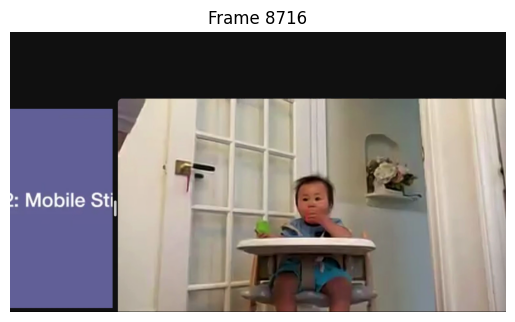

In [39]:
import cv2
import matplotlib.pyplot as plt

video_path = "./demo_vids/M22911_30FPS.mp4"
frame_id = 8716  # 👈 change this

cap = cv2.VideoCapture(video_path)

cap.set(cv2.CAP_PROP_POS_FRAMES, frame_id)
ret, frame = cap.read()

if not ret:
    raise RuntimeError("Failed to read frame")

frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

plt.imshow(frame_rgb)
plt.title(f"Frame {frame_id}")
plt.axis("off")
plt.show()

cap.release()

In [ ]:
# Old video + facial landmark + AUs

# --- VIDEO + FACIAL LANDMARKS + TIME-SERIES WITH MOVING TICKER (4 rows, many columns) ---

import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as mtri
from matplotlib.animation import FFMpegWriter
from pathlib import Path
import math

# ========= CONFIG =========
VIDEO_PATH = "./demo_vids/M22911_12_Arm_Restraint.mov"   # set if needed
OUT_VIDEO  = outdir / "demo_all_things.mp4"

USE_VIDEO_FPS   = True    # if True, use fps from video; else fall back to FPS from config
POINT_SIZE      = 8
MESH_LINEWIDTH  = 0.5

MAX_TS_ROWS     = 4       # <= 4 rows of TS plots, unlimited columns

# ---- CROPPING CONFIG ----
CROP_ENABLED = False       # set False to use full frame
# These are pixel ranges on the ORIGINAL video frame (x: width, y: height).
# CROP_X0 = 550             # left   (inclusive)
# CROP_X1 = 1150            # right  (exclusive)
# CROP_Y0 = 250             # top    (inclusive)
# CROP_Y1 = 950             # bottom (exclusive)

# ========= WHICH TIME-SERIES TO PLOT =========
# -> use ALL numeric columns we previously selected into numeric_cols
plot_cols = ts.columns
n_ts = len(plot_cols)
if n_ts == 0:
    raise RuntimeError("No numeric columns selected for time-series plotting.")

print(f"Plotting {n_ts} time-series on the right.")

# --------- open video and get metadata ----------
cap = cv2.VideoCapture(str(VIDEO_PATH))
if not cap.isOpened():
    raise RuntimeError(f"Could not open video: {VIDEO_PATH}")

vid_w  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
vid_h  = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
vid_fps = cap.get(cv2.CAP_PROP_FPS) or 0.0
total_frames_video = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
total_frames_df    = len(df)

n_frames = min(total_frames_video, total_frames_df)
if n_frames == 0:
    cap.release()
    raise RuntimeError("No frames available to overlay (check video and CSV).")

if USE_VIDEO_FPS and vid_fps > 0:
    out_fps = vid_fps
else:
    out_fps = FPS

print(f"Video size: {vid_w}x{vid_h}, frames: {total_frames_video}, using {n_frames} frames")
print(f"Output FPS: {out_fps}")
print(f"Saving combined video to: {OUT_VIDEO}")

# ---- derive crop box ----
if CROP_ENABLED:
    crop_x0 = max(0, CROP_X0)
    crop_y0 = max(0, CROP_Y0)
    crop_x1 = min(vid_w, CROP_X1)
    crop_y1 = min(vid_h, CROP_Y1)
else:
    crop_x0, crop_y0 = 0, 0
    crop_x1, crop_y1 = vid_w, vid_h

crop_w = crop_x1 - crop_x0
crop_h = crop_y1 - crop_y0
print(f"Using crop box x:[{crop_x0},{crop_x1}), y:[{crop_y0},{crop_y1}) -> {crop_w}x{crop_h}")

# --------- set up figure with gridspec ----------
# read first frame to init background
ret, frame0 = cap.read()
if not ret:
    cap.release()
    raise RuntimeError("Failed to read first frame from video.")

frame0_rgb = cv2.cvtColor(frame0, cv2.COLOR_BGR2RGB)
if CROP_ENABLED:
    frame0_rgb_disp = frame0_rgb[crop_y0:crop_y1, crop_x0:crop_x1]
else:
    frame0_rgb_disp = frame0_rgb

# number of rows (<= MAX_TS_ROWS) and TS columns (unlimited)
n_rows = min(MAX_TS_ROWS, n_ts)
n_ts_cols = math.ceil(n_ts / n_rows)

# Figure height based on rows (more rows -> taller)
fig_height = max(9, 2.8 * n_rows)
fig = plt.figure(figsize=(24, fig_height))

gs = fig.add_gridspec(
    nrows=n_rows,
    ncols=n_ts_cols + 1,       # 1 col for video, rest for TS
    width_ratios=[1.4] + [1] * n_ts_cols
)
gs.update(hspace=0.4, wspace=0.15)

# left big axis: video + landmarks
ax_vid = fig.add_subplot(gs[:, 0])
ax_vid.axis('off')  # no axes/ticks

img_artist = ax_vid.imshow(
    frame0_rgb_disp,
    extent=(0, crop_w, crop_h, 0),
    origin='upper'
)

scatter = ax_vid.scatter([], [], s=POINT_SIZE)
holders = {"mesh": None}
triangles = triang.triangles if (triang is not None) else None

ax_vid.set_xlim(0, crop_w)
ax_vid.set_ylim(crop_h, 0)

# right side: time-series axes
ts_axes = []
ts_vlines = []

x_vals = ts.index.values  # frame indices

for k, cname in enumerate(plot_cols):
    # pack in column-major: 4 rows (max) and as many columns as needed
    row = k % n_rows
    col = k // n_rows     # 0..n_ts_cols-1
    ax_ts = fig.add_subplot(gs[row, col + 1])
    y_vals = ts[cname].values.astype(float)

    ax_ts.plot(x_vals, y_vals, linewidth=1.0)
    ax_ts.set_title(cname, fontsize=8)
    ax_ts.set_xlabel("Frame", fontsize=7)
    ax_ts.set_ylabel("Norm" if NORMALIZE_TIMESERIES else "Value", fontsize=7)

    vline = ax_ts.axvline(
        x_vals[0],
        color='r',
        linestyle='--',
        linewidth=1.0
    )

    ax_ts.tick_params(labelsize=7)
    ts_axes.append(ax_ts)
    ts_vlines.append(vline)

def update_frame(irow, frame_bgr):
    # --- update video + landmarks ---
    frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
    if CROP_ENABLED:
        frame_rgb_disp = frame_rgb[crop_y0:crop_y1, crop_x0:crop_x1]
    else:
        frame_rgb_disp = frame_rgb
    img_artist.set_data(frame_rgb_disp)

    row = df.iloc[irow]
    xs = row[[x_cols[i] for i in idxs]].to_numpy(dtype=float)
    ys = row[[y_cols[i] for i in idxs]].to_numpy(dtype=float)

    # full-frame pixel coords
    xp_full = xs * vid_w
    yp_full = ys * vid_h

    # shift into cropped coordinate system
    xp = xp_full - crop_x0
    yp = yp_full - crop_y0

    scatter.set_offsets(np.c_[xp, yp])

    if triangles is not None:
        tri_pix = mtri.Triangulation(xp, yp, triangles=triangles)
        if holders["mesh"] is not None:
            for coll in holders["mesh"]:
                coll.remove()
        holders["mesh"] = ax_vid.triplot(tri_pix, linewidth=MESH_LINEWIDTH)

    ax_vid.set_xlim(0, crop_w)
    ax_vid.set_ylim(crop_h, 0)

    # --- move ticker in each TS subplot ---
    x_curr = x_vals[irow]
    for vline in ts_vlines:
        vline.set_xdata([x_curr, x_curr])  # needs a sequence

# reset video to beginning (we used one frame already)
cap.set(cv2.CAP_PROP_POS_FRAMES, 0)

writer = FFMpegWriter(
    fps=out_fps,
    metadata=dict(artist="landmark_viz_notebook"),
    bitrate=1800
)

with writer.saving(fig, str(OUT_VIDEO), dpi=150):
    for i in range(n_frames):
        ret, frame = cap.read()
        if not ret:
            break
        update_frame(i, frame)
        writer.grab_frame()

cap.release()
plt.close(fig)
print(f"Saved combined video to: {OUT_VIDEO}")
